In [20]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

In [21]:
df = pd.read_csv("eeg_data.csv")

In [22]:
df

,EEG,Heart,Pressure,Label
0,209,74,131,A
1,256,70,115,A
2,197,89,107,B
3,157,84,134,B
4,178,75,152,C
...,...,...,...,...
11908,159,77,136,D
11909,188,76,140,D
11910,192,74,130,D
11911,198,76,122,D


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11913 entries, 0 to 11912
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   EEG       11913 non-null  int64 
 1   Heart     11913 non-null  int64 
 2   Pressure  11913 non-null  int64 
 3   Label     11913 non-null  object
dtypes: int64(3), object(1)
memory usage: 372.4+ KB


In [24]:
df.isna().sum()

,0
EEG,0
Heart,0
Pressure,0
Label,0


In [25]:
df.describe()

,EEG,Heart,Pressure
count,11913.000000,11913.000000,11913.000000
mean,192.736842,77.406447,134.055653
std,37.319064,5.316131,18.723000
min,150.000000,70.000000,100.000000
25%,166.000000,73.000000,120.000000
50%,183.000000,77.000000,133.000000
75%,200.000000,80.000000,148.000000
max,300.000000,90.000000,170.000000


In [26]:
df

,EEG,Heart,Pressure,Label
0,209,74,131,A
1,256,70,115,A
2,197,89,107,B
3,157,84,134,B
4,178,75,152,C
...,...,...,...,...
11908,159,77,136,D
11909,188,76,140,D
11910,192,74,130,D
11911,198,76,122,D


In [27]:
df.columns

Index(['EEG', 'Heart', 'Pressure', 'Label'], dtype='object')

In [28]:
df['Label'].value_counts()

,count
Label,
C,4188
B,2912
A,2824
D,1989


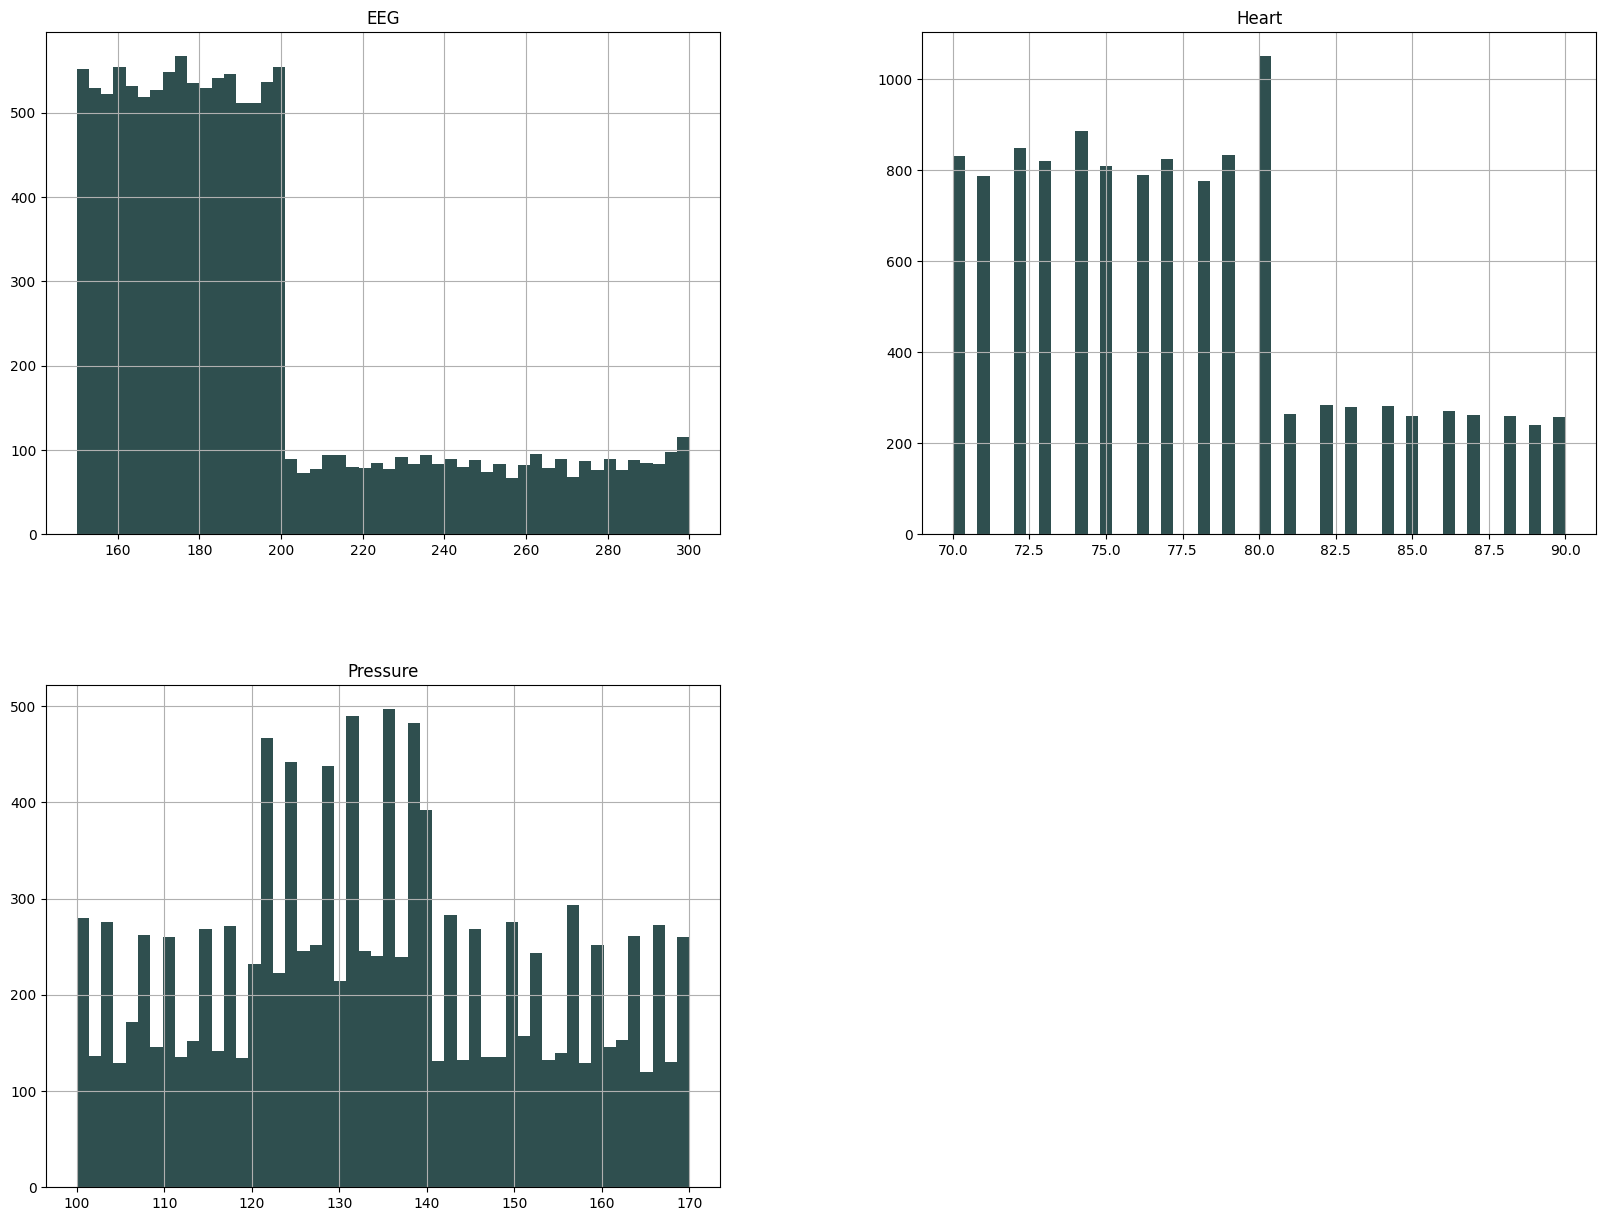

In [29]:
df.hist(bins=50, figsize =(20,15), color = 'darkslategrey')
plt.show(block=False)

In [30]:
df

,EEG,Heart,Pressure,Label
0,209,74,131,A
1,256,70,115,A
2,197,89,107,B
3,157,84,134,B
4,178,75,152,C
...,...,...,...,...
11908,159,77,136,D
11909,188,76,140,D
11910,192,74,130,D
11911,198,76,122,D


In [31]:
X=df.drop(['Label'],axis=1)
y=df["Label"]

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(9530, 3) (2383, 3) (9530,) (2383,)


In [33]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
y_pred = KNN.predict(X_test)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
acc=KNN.score(X_train, y_train)
print(f"Accuracy: {acc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9814270724029381
Precision: 0.9664150497612282
Recall: 0.9692442781104519
F1 Score: 0.967751281290264


In [35]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [36]:
y_pred = gnb.predict(X_test)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
acc=gnb.score(X_train, y_train)
print(f"Accuracy: {acc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.970514165792235
Precision: 0.9690179071157401
Recall: 0.965231424666084
F1 Score: 0.9670094656840972


In [37]:
df

,EEG,Heart,Pressure,Label
0,209,74,131,A
1,256,70,115,A
2,197,89,107,B
3,157,84,134,B
4,178,75,152,C
...,...,...,...,...
11908,159,77,136,D
11909,188,76,140,D
11910,192,74,130,D
11911,198,76,122,D


In [43]:
result= KNN.predict(np.array([[250,72,130]]))
if result[0]=='A':
  print("Abnormal EEG")
elif result[0]=='B':
  print("Abnormal Heart-rate")
elif result[0]=='C':
  print("Abnormal Pressure")
else:
  print("Normal")

Abnormal EEG


In [44]:
result= KNN.predict(np.array([[180,86,130]]))
if result[0]=='A':
  print("Abnormal EEG")
elif result[0]=='B':
  print("Abnormal Heart-rate")
elif result[0]=='C':
  print("Abnormal Pressure")
else:
  print("Normal")

Abnormal Heart-rate


In [45]:
result= KNN.predict(np.array([[180,72,150]]))
if result[0]=='A':
  print("Abnormal EEG")
elif result[0]=='B':
  print("Abnormal Heart-rate")
elif result[0]=='C':
  print("Abnormal Pressure")
else:
  print("Normal")

Abnormal Pressure


In [46]:
result= KNN.predict(np.array([[180,72,125]]))
if result[0]=='A':
  print("Abnormal EEG")
elif result[0]=='B':
  print("Abnormal Heart-rate")
elif result[0]=='C':
  print("Abnormal Pressure")
else:
  print("Normal")

Normal


In [42]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
KNN_filename = 'KNN.pkl'
# Open the file to save as pkl file
KNN_Model_pkl = open(KNN_filename, 'wb')
pickle.dump(KNN, KNN_Model_pkl)
# Close the pickle instances
KNN_Model_pkl.close()

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_true and y_pred are already defined in the dataset processing
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for EEG-Based Stress Classification")
plt.show()

# Print classification report
print(classification_report(y_true, y_pred))
